(pl)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# Polars

```{index} single: Python; Polars
```

علاوه بر آنچه در Anaconda موجود است، این درس به کتابخانه‌های زیر نیاز دارد:

In [1]:
!pip install --upgrade polars yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/847.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 23.4 MB/s  0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/57.3 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 30.9/57.3 MB 155.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 128.3 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [polars-runtime-32]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [polars-runtime-32]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [polars-runtime-32]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [polars-runtime-32]
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [polars]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [polars]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/847.1 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 23.4 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/57.3 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 30.9/57.3 MB 155.1 MB/s eta 0:00:01

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [polars-runtime-32]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [polars-runtime-32]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [polars-runtime-32]

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [polars]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [polars]


## مروری کلی

[Polars](https://pola.rs/) یک کتابخانه سریع دستکاری داده برای Python است که به زبان Rust نوشته شده است.

این کتابخانه به دلیل مزیت‌های عملکردی خود به عنوان جایگزینی مدرن برای {doc}`pandas <pandas>` محبوبیت قابل‌توجهی کسب کرده است.

Polars با در نظر گرفتن عملکرد و کارایی حافظه طراحی شده و از موارد زیر بهره می‌برد:

* [قالب ستونی Apache Arrow](https://arrow.apache.org/docs/format/Columnar.html) برای دسترسی سریع به داده
* [ارزیابی تنبل](https://en.wikipedia.org/wiki/Lazy_evaluation) برای بهینه‌سازی اجرای پرس‌وجو
* پردازش موازی برای استفاده از تمام هسته‌های پردازنده در دسترس
* یک رابط برنامه‌نویسی گویا که حول عبارات ستونی ساخته شده است

```{tip}
*چرا Polars را به‌جای pandas در نظر بگیریم؟*

* **حافظه**: pandas معمولاً به ۵ تا ۱۰ برابر حجم مجموعه داده شما نیاز به RAM دارد؛ Polars تنها به ۲ تا ۴ برابر نیاز دارد
* **سرعت**: Polars برای بسیاری از عملیات رایج ۱۰ تا ۱۰۰ برابر سریع‌تر است
* **مشاهده کنید**: [معیارهای TPC-H در Polars](https://www.pola.rs/benchmarks/) برای مقایسه‌های عملکردی به‌روز
```

در طول این درس، فرض می‌کنیم که واردسازی‌های زیر انجام شده است

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

مانند {doc}`pandas`، Polars دو نوع داده مهم تعریف می‌کند: `Series` و `DataFrame`.

می‌توانید `Series` را به عنوان یک ستون داده در نظر بگیرید، مانند مجموعه‌ای از مشاهدات یک متغیر واحد.

`DataFrame` یک شیء دوبعدی برای ذخیره ستون‌های مرتبط داده است.

## Series

```{index} single: Polars; Series
```

بیایید با Series شروع کنیم.

ابتدا سری‌ای از چهار مشاهده تصادفی می‌سازیم

In [3]:
s = pl.Series(name='daily returns', values=np.random.randn(4))
s

daily returns
f64
1.486557
1.118068
0.38464
0.156635


```{note}
برخلاف Series در {doc}`pandas <pandas>`، Series در Polars هیچ نمایه ردیفی ندارند.
Polars ستون‌محور است --- دسترسی به داده از طریق عبارات ستونی
و ماسک‌های بولی مدیریت می‌شود، نه برچسب‌های ردیف.
برای جزئیات بیشتر [راهنمای مهاجرت Polars برای کاربران pandas](https://docs.pola.rs/user-guide/migration/pandas/) را ببینید.
```

`Series` در Polars بر پایه آرایه‌های [Apache Arrow](https://arrow.apache.org/) ساخته شده‌اند و از بسیاری از عملیات آشنا پشتیبانی می‌کنند

In [4]:
s * 100

daily returns
f64
148.655749
111.806849
38.464045
15.663515


مقادیر مطلق به عنوان یک متد در دسترس هستند

In [5]:
s.abs()

daily returns
f64
1.486557
1.118068
0.38464
0.156635


همچنین می‌توانیم آمار خلاصه سریع دریافت کنیم

In [6]:
s.describe()

statistic,value
str,f64
"""count""",4.0
"""null_count""",0.0
"""mean""",0.786475
"""std""",0.621353
"""min""",0.156635
"""25%""",0.38464
"""50%""",1.118068
"""75%""",1.118068
"""max""",1.486557


از آنجا که Polars هیچ نمایه ردیفی ندارد، داده‌های برچسب‌دار به `DataFrame` نیاز دارند.

برای مثال، برای مرتبط کردن نمادهای معاملاتی با بازده‌ها:

In [7]:
df = pl.DataFrame({
    'company': ['AMZN', 'AAPL', 'MSFT', 'GOOG'],
    'daily returns': np.random.randn(4)
})
df

company,daily returns
str,f64
"""AMZN""",-0.582233
"""AAPL""",-0.133717
"""MSFT""",0.044996
"""GOOG""",-0.87905


با فیلتر کردن بر روی یک عبارت ستونی به یک مقدار دسترسی پیدا می‌کنیم

In [8]:
df.filter(
    pl.col('company') == 'AMZN'
).select('daily returns').item()

-0.5822325458777632

به‌روزرسانی‌ها نیز از عبارات به‌جای تخصیص نمایه استفاده می‌کنند

In [9]:
df = df.with_columns(
    pl.when(pl.col('company') == 'AMZN')
    .then(0)
    .otherwise(pl.col('daily returns'))
    .alias('daily returns')
)
df

company,daily returns
str,f64
"""AMZN""",0.0
"""AAPL""",-0.133717
"""MSFT""",0.044996
"""GOOG""",-0.87905


می‌توانیم عضویت را نیز بررسی کنیم

In [10]:
'AAPL' in df['company']

True

## DataFrameها

```{index} single: Polars; DataFrames
```

در حالی که `Series` یک ستون منفرد از داده است، `DataFrame` چندین ستون است، یکی برای هر متغیر.

مانند {doc}`pandas`، بیایید با داده‌های [Penn World Tables](https://www.rug.nl/ggdc/productivity/pwt/pwt-releases/pwt-7.0) کار کنیم.

این را با `pl.read_csv` می‌خوانیم

In [11]:
url = ('https://raw.githubusercontent.com/QuantEcon/'
       'lecture-python-programming/main/lectures/_static/'
       'lecture_specific/pandas/data/test_pwt.csv')
df = pl.read_csv(url)
df

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""Argentina""","""ARG""",2000,37335.653,0.9995,295072.21869,75.716805,5.578804
"""Australia""","""AUS""",2000,19053.186,1.72483,541804.6521,67.759026,6.720098
"""India""","""IND""",2000,1.0063e6,44.9416,1.7281e6,64.575551,14.072206
"""Israel""","""ISR""",2000,6114.57,4.07733,129253.89423,64.436451,10.266688
"""Malawi""","""MWI""",2000,11801.505,59.543808,5026.221784,74.707624,11.658954
"""South Africa""","""ZAF""",2000,45064.098,6.93983,227242.36949,72.71871,5.726546
"""United States""","""USA""",2000,282171.957,1.0,9.8987e6,72.347054,6.032454
"""Uruguay""","""URY""",2000,3219.793,12.099592,25255.961693,78.97874,5.108068


### انتخاب داده

می‌توانیم ردیف‌ها را با برش‌دهی و ستون‌ها را با نام انتخاب کنیم

In [12]:
df[2:5]

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""India""","""IND""",2000,1.0063e6,44.9416,1.7281e6,64.575551,14.072206
"""Israel""","""ISR""",2000,6114.57,4.07733,129253.89423,64.436451,10.266688
"""Malawi""","""MWI""",2000,11801.505,59.543808,5026.221784,74.707624,11.658954


برای انتخاب ستون‌های خاص، فهرستی از نام‌ها را به `select` بدهید

In [13]:
df.select(['country', 'tcgdp'])

country,tcgdp
str,f64
"""Argentina""",295072.21869
"""Australia""",541804.6521
"""India""",1.7281e6
"""Israel""",129253.89423
"""Malawi""",5026.221784
"""South Africa""",227242.36949
"""United States""",9.8987e6
"""Uruguay""",25255.961693


اینها می‌توانند ترکیب شوند

In [14]:
df[2:5].select(['country', 'tcgdp'])

country,tcgdp
str,f64
"""India""",1.7281e6
"""Israel""",129253.89423
"""Malawi""",5026.221784


### فیلتر کردن بر اساس شرایط

متد `filter` عبارات بولی ساخته‌شده از `pl.col` را می‌پذیرد

In [15]:
df.filter(pl.col('POP') >= 20000)

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""Argentina""","""ARG""",2000,37335.653,0.9995,295072.21869,75.716805,5.578804
"""India""","""IND""",2000,1.0063e6,44.9416,1.7281e6,64.575551,14.072206
"""South Africa""","""ZAF""",2000,45064.098,6.93983,227242.36949,72.71871,5.726546
"""United States""","""USA""",2000,282171.957,1.0,9.8987e6,72.347054,6.032454


چندین شرط می‌توانند با `&` (و) و `|` (یا) ترکیب شوند

In [16]:
df.filter(
    (pl.col('country').is_in(['Argentina', 'India', 'South Africa'])) &
    (pl.col('POP') > 40000)
)

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""India""","""IND""",2000,1.0063e6,44.9416,1.7281e6,64.575551,14.072206
"""South Africa""","""ZAF""",2000,45064.098,6.93983,227242.36949,72.71871,5.726546


عبارات می‌توانند شامل عملیات حسابی بین ستون‌ها باشند

In [17]:
df.filter(
    (pl.col('cc') + pl.col('cg') >= 80) & (pl.col('POP') <= 20000)
)

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""Malawi""","""MWI""",2000,11801.505,59.543808,5026.221784,74.707624,11.658954
"""Uruguay""","""URY""",2000,3219.793,12.099592,25255.961693,78.97874,5.108068


کشوری با بزرگ‌ترین سهم مصرف خانوار را انتخاب کنید

In [18]:
df.filter(pl.col('cc') == pl.col('cc').max())

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""Uruguay""","""URY""",2000,3219.793,12.099592,25255.961693,78.97874,5.108068


### عبارات ستونی

یک تفاوت کلیدی با pandas این است که Polars از **عبارات ستونی** برای تبدیل‌ها استفاده می‌کند، نه فراخوانی‌های عنصر به عنصر `apply`.

در اینجا مثالی برای محاسبه بیشینه هر ستون عددی آورده شده است

In [19]:
df.select(
    pl.col(['year', 'POP', 'XRAT', 'tcgdp', 'cc', 'cg'])
    .max()
    .name.suffix('_max')
)

year_max,POP_max,XRAT_max,tcgdp_max,cc_max,cg_max
i64,f64,f64,f64,f64,f64
2000,1.0063e6,59.543808,9.8987e6,78.97874,14.072206


عبارات می‌توانند در داخل `with_columns` برای افزودن یا تغییر ستون‌ها استفاده شوند

In [20]:
df.with_columns(
    (pl.col('XRAT') / 10).alias('XRAT_scaled'),
    pl.col(pl.Float64).round(2)
)

country,country isocode,year,POP,XRAT,tcgdp,cc,cg,XRAT_scaled
str,str,i64,f64,f64,f64,f64,f64,f64
"""Argentina""","""ARG""",2000,37335.65,1.0,295072.22,75.72,5.58,0.09995
"""Australia""","""AUS""",2000,19053.19,1.72,541804.65,67.76,6.72,0.172483
"""India""","""IND""",2000,1006300.3,44.94,1.7281e6,64.58,14.07,4.49416
"""Israel""","""ISR""",2000,6114.57,4.08,129253.89,64.44,10.27,0.407733
"""Malawi""","""MWI""",2000,11801.5,59.54,5026.22,74.71,11.66,5.954381
"""South Africa""","""ZAF""",2000,45064.1,6.94,227242.37,72.72,5.73,0.693983
"""United States""","""USA""",2000,282171.96,1.0,9.8987e6,72.35,6.03,0.1
"""Uruguay""","""URY""",2000,3219.79,12.1,25255.96,78.98,5.11,1.209959


منطق شرطی از `pl.when(...).then(...).otherwise(...)` استفاده می‌کند

In [21]:
df.with_columns(
    pl.when(pl.col('POP') >= 20000)
    .then(pl.col('POP'))
    .otherwise(None)
    .alias('POP_filtered')
).select(['country', 'POP', 'POP_filtered'])

country,POP,POP_filtered
str,f64,f64
"""Argentina""",37335.653,37335.653
"""Australia""",19053.186,null
"""India""",1.0063e6,1.0063e6
"""Israel""",6114.57,null
"""Malawi""",11801.505,null
"""South Africa""",45064.098,45064.098
"""United States""",282171.957,282171.957
"""Uruguay""",3219.793,null


```{note}
Polars `map_elements` را به عنوان راه فراری برای اعمال توابع دلخواه
Python به‌صورت ردیف‌به‌ردیف ارائه می‌دهد، اما این کار موتور بهینه‌شده عبارات
را دور می‌زند و در صورت وجود عبارت بومی باید از آن اجتناب شود.
```

### مقادیر گم‌شده

بیایید برخی مقادیر تهی را برای نمایش تکنیک‌های جایگذاری وارد کنیم

In [22]:
df_nulls = df.with_row_index().with_columns(
    pl.when(pl.col('index') == 0)
    .then(None).otherwise(pl.col('XRAT')).alias('XRAT'),
    pl.when(pl.col('index') == 3)
    .then(None).otherwise(pl.col('cc')).alias('cc'),
    pl.when(pl.col('index') == 5)
    .then(None).otherwise(pl.col('tcgdp')).alias('tcgdp'),
    pl.when(pl.col('index') == 6)
    .then(None).otherwise(pl.col('POP')).alias('POP'),
).drop('index')
df_nulls

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""Argentina""","""ARG""",2000,37335.653,null,295072.21869,75.716805,5.578804
"""Australia""","""AUS""",2000,19053.186,1.72483,541804.6521,67.759026,6.720098
"""India""","""IND""",2000,1.0063e6,44.9416,1.7281e6,64.575551,14.072206
"""Israel""","""ISR""",2000,6114.57,4.07733,129253.89423,null,10.266688
"""Malawi""","""MWI""",2000,11801.505,59.543808,5026.221784,74.707624,11.658954
"""South Africa""","""ZAF""",2000,45064.098,6.93983,null,72.71871,5.726546
"""United States""","""USA""",2000,null,1.0,9.8987e6,72.347054,6.032454
"""Uruguay""","""URY""",2000,3219.793,12.099592,25255.961693,78.97874,5.108068


تمام مقادیر تهی را با صفر پر کنید

In [23]:
df_nulls.fill_null(0)

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""Argentina""","""ARG""",2000,37335.653,0.0,295072.21869,75.716805,5.578804
"""Australia""","""AUS""",2000,19053.186,1.72483,541804.6521,67.759026,6.720098
"""India""","""IND""",2000,1.0063e6,44.9416,1.7281e6,64.575551,14.072206
"""Israel""","""ISR""",2000,6114.57,4.07733,129253.89423,0.0,10.266688
"""Malawi""","""MWI""",2000,11801.505,59.543808,5026.221784,74.707624,11.658954
"""South Africa""","""ZAF""",2000,45064.098,6.93983,0.0,72.71871,5.726546
"""United States""","""USA""",2000,0.0,1.0,9.8987e6,72.347054,6.032454
"""Uruguay""","""URY""",2000,3219.793,12.099592,25255.961693,78.97874,5.108068


یا با میانگین‌های ستونی پر کنید

In [24]:
cols = ['cc', 'tcgdp', 'POP', 'XRAT']
df_nulls.with_columns(
    pl.col(cols).fill_null(pl.col(cols).mean())
)

country,country isocode,year,POP,XRAT,tcgdp,cc,cg
str,str,i64,f64,f64,f64,f64,f64
"""Argentina""","""ARG""",2000,37335.653,18.618141,295072.21869,75.716805,5.578804
"""Australia""","""AUS""",2000,19053.186,1.72483,541804.6521,67.759026,6.720098
"""India""","""IND""",2000,1.0063e6,44.9416,1.7281e6,64.575551,14.072206
"""Israel""","""ISR""",2000,6114.57,4.07733,129253.89423,72.400502,10.266688
"""Malawi""","""MWI""",2000,11801.505,59.543808,5026.221784,74.707624,11.658954
"""South Africa""","""ZAF""",2000,45064.098,6.93983,1.8033e6,72.71871,5.726546
"""United States""","""USA""",2000,161269.871714,1.0,9.8987e6,72.347054,6.032454
"""Uruguay""","""URY""",2000,3219.793,12.099592,25255.961693,78.97874,5.108068


Polars همچنین از پر کردن رو به جلو (`fill_null(strategy='forward')`) و درون‌یابی پشتیبانی می‌کند.

[ابزارهای جایگذاری پیشرفته‌تری](https://scikit-learn.org/stable/modules/impute.html) در scikit-learn در دسترس هستند.

### تجسم‌سازی

بیایید یک ستون تولید ناخالص داخلی سرانه بسازیم و آن را رسم کنیم

In [25]:
df = (df
    .select(['country', 'POP', 'tcgdp'])
    .rename({'POP': 'population', 'tcgdp': 'total GDP'})
    .with_columns(
        (pl.col('population') * 1e3).alias('population')
    )
    .with_columns(
        (pl.col('total GDP') * 1e6 / pl.col('population'))
        .alias('GDP percap')
    )
    .sort('GDP percap', descending=True)
)
df

country,population,total GDP,GDP percap
str,f64,f64,f64
"""United States""",2.82171957e8,9.8987e6,35080.381854
"""Australia""",1.9053186e7,541804.6521,28436.433261
"""Israel""",6.11457e6,129253.89423,21138.672749
"""Argentina""",3.7335653e7,295072.21869,7903.229085
"""Uruguay""",3.219793e6,25255.961693,7843.97062
"""South Africa""",4.5064098e7,227242.36949,5042.647686
"""India""",1.0063e9,1.7281e6,1717.324719
"""Malawi""",1.1801505e7,5026.221784,425.896679


می‌توانیم ستون‌ها را مستقیماً برای matplotlib استخراج کنیم

```{note}
Polars همچنین یک [رابط برنامه‌نویسی رسم داخلی](https://docs.pola.rs/user-guide/misc/visualization/)
مبتنی بر Altair ارائه می‌دهد (به عنوان مثال، `df.plot.bar(x=..., y=...)`).
ما در اینجا از matplotlib برای هماهنگی با بقیه سری درس‌ها استفاده می‌کنیم.
```

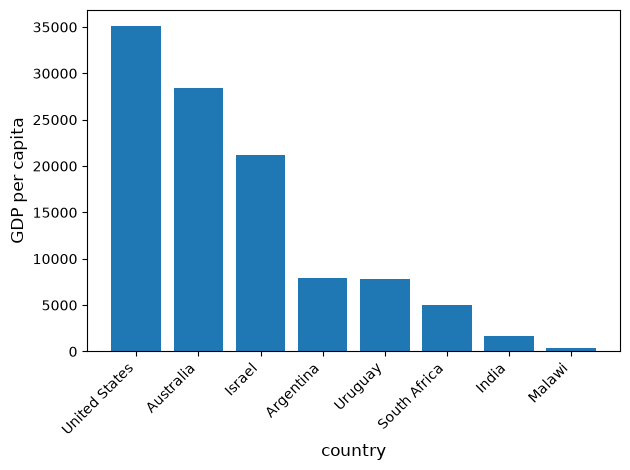

In [26]:
fig, ax = plt.subplots()
ax.bar(df['country'].to_list(), df['GDP percap'].to_list())
ax.set_xlabel('country', fontsize=12)
ax.set_ylabel('GDP per capita', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## ارزیابی تنبل

```{index} single: Polars; Lazy Evaluation
```

یکی از قدرتمندترین ویژگی‌های Polars **ارزیابی تنبل** است.

به‌جای اجرای فوری هر عملیات، حالت تنبل کل برنامه پرس‌وجو را جمع‌آوری کرده و پیش از اجرا آن را بهینه می‌کند.

### مشتاق در برابر تنبل

In [27]:
# Reload the dataset
url = ('https://raw.githubusercontent.com/QuantEcon/'
       'lecture-python-programming/main/lectures/_static/'
       'lecture_specific/pandas/data/test_pwt.csv')
df_full = pl.read_csv(url)

رابط برنامه‌نویسی **مشتاق (eager)** بلافاصله اجرا می‌شود (مانند pandas)

In [28]:
result_eager = (df_full
    .filter(pl.col('tcgdp') > 1000)
    .select(['country', 'year', 'tcgdp'])
    .sort('tcgdp', descending=True)
)
result_eager.head()

country,year,tcgdp
str,i64,f64
"""United States""",2000,9.8987e6
"""India""",2000,1.7281e6
"""Australia""",2000,541804.6521
"""Argentina""",2000,295072.21869
"""South Africa""",2000,227242.36949


رابط برنامه‌نویسی **تنبل (lazy)** در عوض یک برنامه پرس‌وجو می‌سازد

In [29]:
lazy_query = (df_full.lazy()
    .filter(pl.col('tcgdp') > 1000)
    .select(['country', 'year', 'tcgdp'])
    .sort('tcgdp', descending=True)
)
print(lazy_query.explain())

SORT BY [descending: [true]] [col("tcgdp")]
  FILTER col("tcgdp") > 1000.0
  FROM
    DF ["country", "country isocode", "year", "POP", ...]; PROJECT["country", "year", "tcgdp"] 3/8 COLUMNS


برای اجرای برنامه، `collect` را فراخوانی کنید

In [30]:
result_lazy = lazy_query.collect()
result_lazy.head()

country,year,tcgdp
str,i64,f64
"""United States""",2000,9.8987e6
"""India""",2000,1.7281e6
"""Australia""",2000,541804.6521
"""Argentina""",2000,295072.21869
"""South Africa""",2000,227242.36949


### بهینه‌سازی پرس‌وجو

موتور تنبل به‌طور خودکار چندین بهینه‌سازی را اعمال می‌کند:

* **فشار محمول (predicate pushdown)** --- فیلترها در اسرع وقت اعمال می‌شوند
* **فشار تصویر (projection pushdown)** --- فقط ستون‌های مورد نیاز از منبع خوانده می‌شوند
* **حذف زیرعبارت مشترک** --- محاسبات تکراری ادغام می‌شوند

بیایید ببینیم Polars چگونه یک پرس‌وجوی چندمرحله‌ای را بازنویسی می‌کند

In [31]:
optimized = (df_full.lazy()
    .select(['country', 'year', 'tcgdp', 'POP'])
    .filter(pl.col('tcgdp') > 500)
    .with_columns(
        (pl.col('tcgdp') / pl.col('POP')).alias('gdp_per_capita')
    )
    .filter(pl.col('gdp_per_capita') > 10)
    .select(['country', 'year', 'gdp_per_capita'])
)

print("Optimized plan:")
print(optimized.explain())

Optimized plan:
FILTER col("gdp_per_capita") > 10.0
FROM
  simple π 3/3 ["country", "year", ... 1 other column]
     WITH_COLUMNS:
     [(col("tcgdp") / col("POP")).alias("gdp_per_capita")] 
      FILTER col("tcgdp") > 500.0
      FROM
        DF ["country", "country isocode", "year", "POP", ...]; PROJECT["country", "year", "tcgdp", "POP"] 4/8 COLUMNS


اجرای برنامه نتیجه نهایی را به ما می‌دهد

In [32]:
optimized.collect()

country,year,gdp_per_capita
str,i64,f64
"""Australia""",2000,28.436433
"""Israel""",2000,21.138673
"""United States""",2000,35.080382


### مقایسه عملکرد

بیایید pandas، Polars مشتاق، و Polars تنبل را روی همان کار مقایسه کنیم.

ابتدا با یک مجموعه داده کوچک (همان Penn World Tables که در بالا استفاده کردیم) شروع می‌کنیم تا نشان دهیم
که برای داده‌های کوچک تفاوت‌ها ناچیز هستند

In [33]:
import pandas as pd
import time

# Small dataset -- Penn World Tables (~8 rows)
url = ('https://raw.githubusercontent.com/QuantEcon/'
       'lecture-python-programming/main/lectures/_static/'
       'lecture_specific/pandas/data/test_pwt.csv')
small_pd = pd.read_csv(url)
small_pl = pl.read_csv(url)

اکنون همان عملیات فیلتر-انتخاب-مرتب‌سازی را در هر کتابخانه زمان‌بندی می‌کنیم

In [34]:
# pandas
start = time.perf_counter()
_ = (small_pd
     .query('tcgdp > 500')
     [['country', 'year', 'tcgdp', 'POP']]
     .assign(gdp_pc=lambda d: d['tcgdp'] / d['POP'])
     .sort_values('gdp_pc', ascending=False))
pd_small = time.perf_counter() - start

# Polars eager
start = time.perf_counter()
_ = (small_pl
     .filter(pl.col('tcgdp') > 500)
     .select(['country', 'year', 'tcgdp', 'POP'])
     .with_columns((pl.col('tcgdp') / pl.col('POP')).alias('gdp_pc'))
     .sort('gdp_pc', descending=True))
pl_small = time.perf_counter() - start

print(f"Small data  --  pandas: {pd_small:.4f}s | Polars eager: {pl_small:.4f}s")

Small data  --  pandas: 0.0055s | Polars eager: 0.0010s


روی تعداد اندکی ردیف، تفاوت سرعت ناچیز است --- از هر رابط برنامه‌نویسی که
راحت‌تر می‌یابید استفاده کنید.

اکنون بیایید مقیاس را به ۵ میلیون ردیف بزرگ کنیم که تفاوت واضح می‌شود.

کار این است: فیلتر کردن ردیف‌هایی که `value > 0`، محاسبه یک حاصل‌ضرب وزنی
`value * weight`، سپس گرفتن میانگین آن حاصل‌ضرب در هر گروه ---
یک میانگین وزنی گروه‌بندی‌شده.

In [35]:
n = 5_000_000
np.random.seed(42)

groups = np.random.choice(['A', 'B', 'C', 'D'], n)
values = np.random.randn(n)
weights = np.random.rand(n)
extra1 = np.random.randn(n)
extra2 = np.random.randn(n)

big_pd = pd.DataFrame({
    'group': groups, 'value': values,
    'weight': weights, 'extra1': extra1, 'extra2': extra2
})
big_pl = pl.DataFrame({
    'group': groups, 'value': values,
    'weight': weights, 'extra1': extra1, 'extra2': extra2
})

ابتدا، خط پایه pandas

In [36]:
start = time.perf_counter()
tmp = big_pd[big_pd['value'] > 0][['group', 'value', 'weight']].copy()
tmp['weighted'] = tmp['value'] * tmp['weight']
_ = tmp.groupby('group')['weighted'].mean()
pd_time = time.perf_counter() - start
print(f"pandas:       {pd_time:.4f}s")

pandas:       0.1233s


سپس، Polars در حالت مشتاق

In [37]:
start = time.perf_counter()
_ = (big_pl
    .filter(pl.col('value') > 0)
    .select(['group', 'value', 'weight'])
    .with_columns(
        (pl.col('value') * pl.col('weight')).alias('weighted'))
    .group_by('group')
    .agg(pl.col('weighted').mean()))
eager_time = time.perf_counter() - start
print(f"Polars eager: {eager_time:.4f}s")

Polars eager: 0.0350s


و در نهایت، Polars در حالت تنبل

In [38]:
start = time.perf_counter()
_ = (big_pl.lazy()
    .filter(pl.col('value') > 0)
    .select(['group', 'value', 'weight'])
    .with_columns(
        (pl.col('value') * pl.col('weight')).alias('weighted'))
    .group_by('group')
    .agg(pl.col('weighted').mean())
    .collect())
lazy_time = time.perf_counter() - start
print(f"Polars lazy:  {lazy_time:.4f}s")

Polars lazy:  0.0292s


نکته کلیدی:

* برای **داده‌های کوچک** (هزاران ردیف)، pandas و Polars به‌طور
  مشابهی عمل می‌کنند --- بر اساس ترجیح رابط برنامه‌نویسی و تناسب اکوسیستم انتخاب کنید.
* برای **داده‌های متوسط تا بزرگ** (صدها هزار ردیف و بیشتر)،
  Polars می‌تواند به‌طور قابل‌توجهی سریع‌تر باشد به لطف موتور Rust، اجرای موازی،
  و (در حالت تنبل) بهینه‌سازی پرس‌وجو.

رابط برنامه‌نویسی تنبل هنگام خواندن از دیسک به‌ویژه قدرتمند است --- `scan_csv` مستقیماً یک `LazyFrame` برمی‌گرداند، بنابراین فیلترها و تصویرها به خواننده فایل فشار داده می‌شوند.

```{tip}
از `pl.scan_csv(path)` به‌جای `pl.read_csv(path)` هنگام کار با
فایل‌های CSV بزرگ استفاده کنید.
فقط ستون‌ها و ردیف‌هایی که واقعاً به آن‌ها نیاز دارید از دیسک خوانده می‌شوند.
[مستندات ورودی/خروجی Polars](https://docs.pola.rs/user-guide/io/csv/) را ببینید.
```

## منابع داده آنلاین

```{index} single: Data Sources
```

مانند {doc}`pandas`، Python پرس‌وجوی پایگاه‌های داده آنلاین را ساده می‌کند.

یک پایگاه داده مهم برای اقتصاددانان [FRED](https://fred.stlouisfed.org/) است --- مجموعه‌ای گسترده از داده‌های سری زمانی که توسط فدرال رزرو سنت‌لوئیس نگهداری می‌شود.

متد `read_csv` در Polars می‌تواند داده را مستقیماً از یک URL دریافت کند.

از `try_parse_dates=True` برای تجزیه خودکار ستون تاریخ استفاده می‌کنیم

In [39]:
fred_url = ('https://fred.stlouisfed.org/graph/fredgraph.csv?'
            'bgcolor=%23e1e9f0&chart_type=line&drp=0&'
            'fo=open%20sans&graph_bgcolor=%23ffffff&'
            'height=450&mode=fred&recession_bars=on&'
            'txtcolor=%23444444&ts=12&tts=12&width=1318&'
            'nt=0&thu=0&trc=0&show_legend=yes&'
            'show_axis_titles=yes&show_tooltip=yes&'
            'id=UNRATE&scale=left&cosd=1948-01-01&'
            'coed=2024-06-01&line_color=%234572a7&'
            'link_values=false&line_style=solid&'
            'mark_type=none&mw=3&lw=2&ost=-99999&'
            'oet=99999&mma=0&fml=a&fq=Monthly&fam=avg&'
            'fgst=lin&fgsnd=2020-02-01&line_index=1&'
            'transformation=lin&vintage_date=2024-07-29&'
            'revision_date=2024-07-29&nd=1948-01-01')
data = pl.read_csv(fred_url, try_parse_dates=True)

بیایید چند ردیف اول را بررسی کنیم

In [40]:
data.head()

observation_date,UNRATE
date,f64
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5


و آمار خلاصه را دریافت کنیم

In [41]:
data.describe()

statistic,observation_date,UNRATE
str,str,f64
"""count""","""918""",918.0
"""null_count""","""0""",0.0
"""mean""","""1986-03-17 06:30:35.294117""",5.693246
"""std""",null,1.710248
"""min""","""1948-01-01""",2.5
"""25%""","""1967-02-01""",4.4
"""50%""","""1986-04-01""",5.5
"""75%""","""2005-05-01""",6.7
"""max""","""2024-06-01""",14.8


نرخ بیکاری از ۲۰۰۶ تا ۲۰۱۲ را رسم کنید

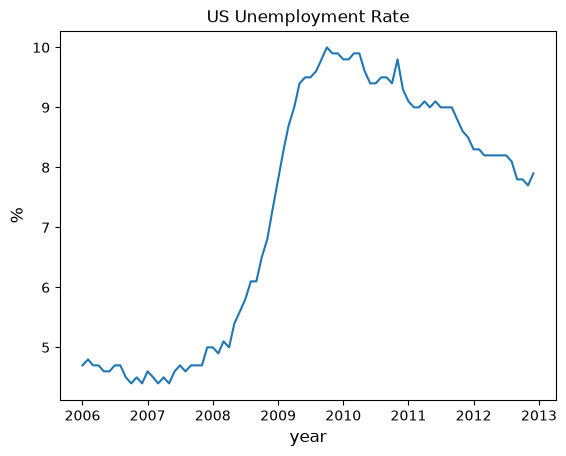

In [42]:
filtered = data.filter(
    (pl.col('observation_date') >= pl.date(2006, 1, 1)) &
    (pl.col('observation_date') <= pl.date(2012, 12, 31))
)

fig, ax = plt.subplots()
ax.plot(filtered['observation_date'].to_list(),
        filtered['UNRATE'].to_list())
ax.set_title('US Unemployment Rate')
ax.set_xlabel('year', fontsize=12)
ax.set_ylabel('%', fontsize=12)
plt.show()

Polars از [فرمت‌های فایل بسیاری](https://docs.pola.rs/user-guide/io/) از جمله Excel، JSON، Parquet، و اتصالات مستقیم پایگاه داده پشتیبانی می‌کند.

## تمرین‌ها

```{exercise-start}
:label: pl_ex1
```

با این واردسازی‌ها:

In [43]:
import datetime as dt
import yfinance as yf

برنامه‌ای بنویسید که تغییر درصدی قیمت را در طول سال ۲۰۲۱ برای سهام‌های زیر محاسبه کند:

In [44]:
ticker_list = {'INTC': 'Intel',
               'MSFT': 'Microsoft',
               'IBM': 'IBM',
               'BHP': 'BHP',
               'TM': 'Toyota',
               'AAPL': 'Apple',
               'AMZN': 'Amazon',
               'C': 'Citigroup',
               'QCOM': 'Qualcomm',
               'KO': 'Coca-Cola',
               'GOOG': 'Google'}

در اینجا تابعی است که قیمت‌های بسته شدن را در یک DataFrame Polars می‌خواند:

In [45]:
def read_data_polars(ticker_list,
                     start=dt.datetime(2021, 1, 1),
                     end=dt.datetime(2021, 12, 31)):
    """
    Read closing price data from Yahoo Finance
    and return a Polars DataFrame.
    """
    dataframes = []

    for tick in ticker_list:
        stock = yf.Ticker(tick)
        prices = stock.history(start=start, end=end)
        df = pl.DataFrame({
            'Date': list(prices.index.date),
            tick: prices['Close'].values
        }).with_columns(pl.col('Date').cast(pl.Date))
        dataframes.append(df)

    result = dataframes[0]
    for df in dataframes[1:]:
        result = result.join(
            df, on='Date', how='full', coalesce=True
        )
    return result.sort('Date')

ticker = read_data_polars(ticker_list)

```{note}
اتصال‌های Polars ترتیب ردیف‌های خروجی را تضمین نمی‌کنند --- کلیدهایی که فقط در یک طرف
مطابقت دارند به‌جای قرار گرفتن در جای خود، اضافه می‌شوند.
این همان تم "بدون نمایه، بدون تراز خودکار" از بالاست: بدون برچسب‌های
ردیف برای تراز کردن، ترتیب چیزی است که به‌طور صریح درخواست می‌کنیم.
به همین دلیل `sort('Date')` قبل از بازگشت قرار دارد، که هر محاسبه بعدی
`first()`/`last()` به آن متکی است.
```

برنامه را برای رسم نتیجه به عنوان یک نمودار میله‌ای کامل کنید.

```{exercise-end}
```

```{solution-start} pl_ex1
:class: dropdown
```

تغییرات درصدی را با استفاده از عبارات Polars محاسبه کنید:

In [46]:
price_change = ticker.select([
    ((pl.col(tick).last() / pl.col(tick).first() - 1) * 100)
    .alias(tick)
    for tick in ticker_list.keys()
]).transpose(
    include_header=True,
    header_name='ticker',
    column_names=['pct_change']
).with_columns(
    pl.col('ticker')
    .replace_strict(ticker_list, default=pl.col('ticker'))
    .alias('company')
).sort('pct_change')

print(price_change)

shape: (11, 3)
┌────────┬────────────┬───────────┐
│ ticker ┆ pct_change ┆ company   │
│ ---    ┆ ---        ┆ ---       │
│ str    ┆ f64        ┆ str       │
╞════════╪════════════╪═══════════╡
│ BHP    ┆ -2.249076  ┆ BHP       │
│ C      ┆ 3.550576   ┆ Citigroup │
│ AMZN   ┆ 5.845049   ┆ Amazon    │
│ INTC   ┆ 6.86852    ┆ Intel     │
│ KO     ┆ 14.922531  ┆ Coca-Cola │
│ …      ┆ …          ┆ …         │
│ TM     ┆ 23.416741  ┆ Toyota    │
│ QCOM   ┆ 25.318529  ┆ Qualcomm  │
│ AAPL   ┆ 38.550791  ┆ Apple     │
│ MSFT   ┆ 57.179627  ┆ Microsoft │
│ GOOG   ┆ 68.9609    ┆ Google    │
└────────┴────────────┴───────────┘


نتایج را مستقیماً با matplotlib رسم کنید:

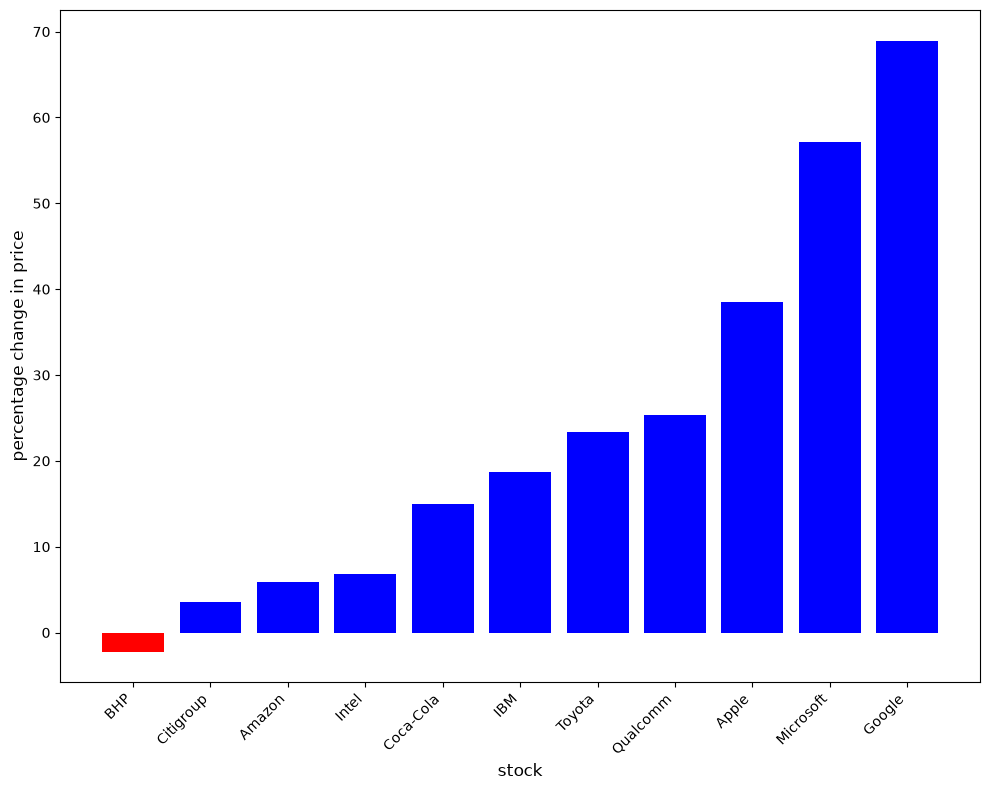

In [47]:
companies = price_change['company'].to_list()
changes = price_change['pct_change'].to_list()
colors = ['red' if x < 0 else 'blue' for x in changes]

fig, ax = plt.subplots(figsize=(10, 8))
ax.bar(companies, changes, color=colors)
ax.set_xlabel('stock', fontsize=12)
ax.set_ylabel('percentage change in price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

```{solution-end}
```


```{exercise-start}
:label: pl_ex2
```

با استفاده از `read_data_polars` از {ref}`pl_ex1`، تغییر درصدی سال به سال را برای این شاخص‌ها بدست آورید:

In [48]:
indices_list = {'^GSPC': 'S&P 500',
               '^IXIC': 'NASDAQ',
               '^DJI': 'Dow Jones',
               '^N225': 'Nikkei'}

نتیجه را به عنوان یک نمودار سری زمانی رسم کنید.

```{exercise-end}
```

```{solution-start} pl_ex2
:class: dropdown
```

In [49]:
indices_data = read_data_polars(
    indices_list,
    start=dt.datetime(1971, 1, 1),
    end=dt.datetime(2021, 12, 31)
)

indices_data = indices_data.with_columns(
    pl.col('Date').dt.year().alias('year')
)

بازده‌های سالانه را با استفاده از عملیات گروه‌بندی محاسبه کنید:

In [50]:
yearly_returns = indices_data.group_by('year').agg([
    *[pl.col(idx).drop_nulls().first().alias(f'{idx}_first')
      for idx in indices_list],
    *[pl.col(idx).drop_nulls().last().alias(f'{idx}_last')
      for idx in indices_list]
])

for idx, name in indices_list.items():
    yearly_returns = yearly_returns.with_columns(
        ((pl.col(f'{idx}_last') - pl.col(f'{idx}_first'))
         / pl.col(f'{idx}_first') * 100).alias(name)
    )

yearly_returns = (yearly_returns
    .select(['year', *indices_list.values()])
    .sort('year')
)
print(yearly_returns)

shape: (51, 5)
┌──────┬────────────┬────────────┬───────────┬────────────┐
│ year ┆ S&P 500    ┆ NASDAQ     ┆ Dow Jones ┆ Nikkei     │
│ ---  ┆ ---        ┆ ---        ┆ ---       ┆ ---        │
│ i32  ┆ f64        ┆ f64        ┆ f64       ┆ f64        │
╞══════╪════════════╪════════════╪═══════════╪════════════╡
│ 1971 ┆ 12.002188  ┆ 14.120003  ┆ null      ┆ 36.407234  │
│ 1972 ┆ 16.110952  ┆ 17.668274  ┆ null      ┆ 92.011231  │
│ 1973 ┆ -18.094035 ┆ -31.523435 ┆ null      ┆ -17.697016 │
│ 1974 ┆ -29.811633 ┆ -35.350697 ┆ null      ┆ -9.914309  │
│ 1975 ┆ 28.4209    ┆ 27.874797  ┆ null      ┆ 16.798024  │
│ …    ┆ …          ┆ …          ┆ …         ┆ …          │
│ 2017 ┆ 18.415027  ┆ 27.155799  ┆ 24.331151 ┆ 16.182267  │
│ 2018 ┆ -7.009394  ┆ -5.303631  ┆ -6.028635 ┆ -14.853703 │
│ 2019 ┆ 28.714796  ┆ 34.603667  ┆ 22.23998  ┆ 20.931737  │
│ 2020 ┆ 15.292907  ┆ 41.751104  ┆ 6.019231  ┆ 18.269064  │
│ 2021 ┆ 29.132182  ┆ 23.964416  ┆ 20.428169 ┆ 5.625169   │
└──────┴────────────┴────

آمار خلاصه:

In [51]:
yearly_returns.select(list(indices_list.values())).describe()

statistic,S&P 500,NASDAQ,Dow Jones,Nikkei
str,f64,f64,f64,f64
"""count""",51.0,51.0,30.0,51.0
"""null_count""",0.0,0.0,21.0,0.0
"""mean""",9.20986,13.094786,9.10453,7.850346
"""std""",16.398012,24.616625,14.134825,24.384181
"""min""",-37.58465,-40.197764,-32.716831,-39.695649
"""25%""",0.255632,2.470561,2.072082,-6.094919
"""50%""",11.677594,14.312575,9.387316,7.667034
"""75%""",19.671602,27.874797,21.451016,20.931737
"""max""",34.157394,84.294285,33.311106,92.011231


هر شاخص را در یک زیرنمودار رسم کنید:

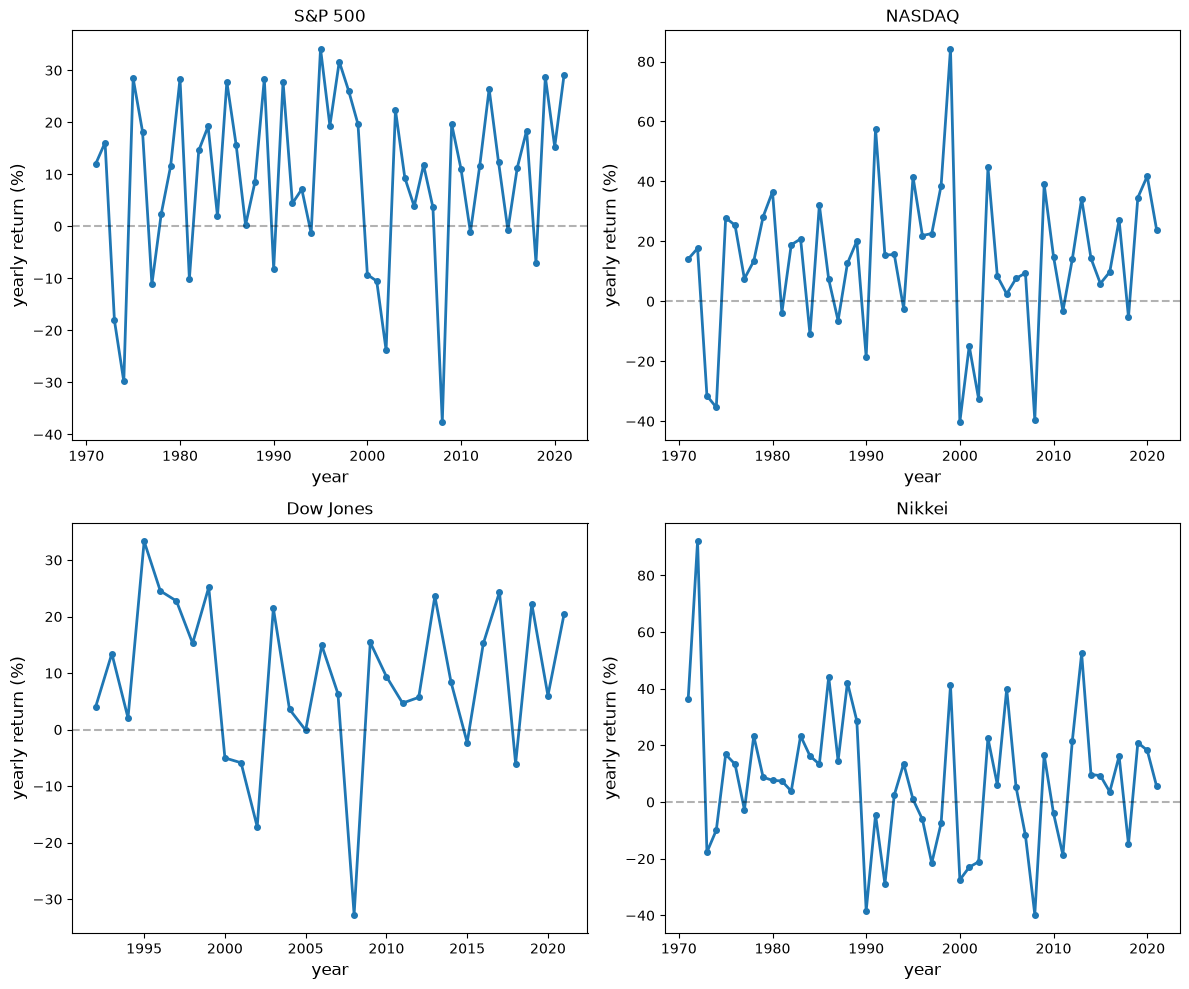

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
years = yearly_returns['year'].to_list()

for iter_, ax in enumerate(axes.flatten()):
    name = list(indices_list.values())[iter_]
    values = yearly_returns[name].to_list()
    ax.plot(years, values, 'o-', linewidth=2, markersize=4)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.set_ylabel('yearly return (%)', fontsize=12)
    ax.set_xlabel('year', fontsize=12)
    ax.set_title(name, fontsize=12)

plt.tight_layout()
plt.show()

```{solution-end}
```